In [7]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
# Load data
df = pd.read_csv("../../Data/ETHUSDT_1h.csv")
df['log_return'] = np.log(df['close'].pct_change() + 1)
df.dropna(inplace=True)

# Set datetime index
df['open_time'] = pd.to_datetime(df['open_time'])
df = df.set_index('open_time')


In [9]:
def run_momentum_backtest(df, window, vol_window=24, k=1.0, z_threshold=0.5, long_only=False):
    """
    Run momentum backtest with volatility scaling.
    
    Parameters:
    - df: DataFrame with 'log_return' column
    - window: Momentum lookback window
    - vol_window: Volatility lookback window
    - k: Scaling factor for tanh
    - z_threshold: Minimum z-score to take position
    - long_only: If True, only long positions allowed
    """
    data = df.copy()

    # 1) Momentum signal
    data['momentum'] = data['log_return'].rolling(window).sum()

    # 2) Volatility estimate (rolling std of log returns)
    data['vol'] = data['log_return'].rolling(vol_window).std()

    data = data.dropna().copy()

    # Avoid division by zero
    data['vol'] = data['vol'].replace(0, np.nan)
    data = data.dropna(subset=['vol']).copy()

    # 3) Volatility scaled signal
    data['z'] = data['momentum'] / data['vol']

    # 4) Smooth bounded exposure
    data['position_raw'] = np.tanh(k * data['z'])  # between -1 and 1

    # 5) Thresholding to avoid chop
    data['position'] = np.where(data['z'].abs() < z_threshold, 0.0, data['position_raw'])

    # 6) Optional long-only
    if long_only:
        data['position'] = np.clip(data['position'], 0.0, 1.0)

    # 7) Apply previous position
    data['position_shifted'] = data['position'].shift(1).fillna(0.0)
    data['strat_return'] = data['position_shifted'] * data['log_return']

    # 8) Equity curve
    data['cum_log'] = data['strat_return'].cumsum()
    data['equity'] = np.exp(data['cum_log'])

    # 9) Percent drawdown
    data['running_max'] = data['equity'].cummax()
    data['drawdown'] = data['equity'] / data['running_max'] - 1
    max_dd = data['drawdown'].min()

    # 10) Performance stats
    bars_per_year = 24 * 365
    mu = data['strat_return'].mean()
    sigma = data['strat_return'].std()

    sharpe = np.nan if sigma == 0 else (mu / sigma) * np.sqrt(bars_per_year)
    volatility = sigma * np.sqrt(bars_per_year)
    total_return = np.exp(data['strat_return'].sum()) - 1

    return {
        'window': window,
        'total_return': total_return,
        'sharpe': sharpe,
        'vol': volatility,
        'max_drawdown': max_dd
    }


In [10]:
def walk_forward_validation(
    df,
    windows,
    train_days=365,
    test_days=90,
    vol_window=24,
    k=1.0,
    z_threshold=0.5,
    long_only=False
):
    """
    Walk-forward validation: select best window on training set, test on out-of-sample data.
    """
    df = df.copy()
    results = []

    # convert days → rows (hourly data)
    train_len = train_days * 24
    test_len = test_days * 24

    start = 0
    end = len(df)

    while start + train_len + test_len < end:

        train = df.iloc[start : start + train_len]
        test = df.iloc[start + train_len : start + train_len + test_len]

        # select best window on training data
        best_sharpe = -999
        best_window = None

        for w in windows:
            try:
                res = run_momentum_backtest(
                    train,
                    window=w,
                    vol_window=vol_window,
                    k=k,
                    z_threshold=z_threshold,
                    long_only=long_only
                )
                if res['sharpe'] > best_sharpe:
                    best_sharpe = res['sharpe']
                    best_window = w
            except:
                continue

        # evaluate chosen window on test data
        test_res = run_momentum_backtest(
            test,
            window=best_window,
            vol_window=vol_window,
            k=k,
            z_threshold=z_threshold,
            long_only=long_only
        )

        # attach metadata
        test_res['best_window'] = best_window
        test_res['train_range'] = f"{train.index[0]} → {train.index[-1]}"
        test_res['test_range'] = f"{test.index[0]} → {test.index[-1]}"

        results.append(test_res)

        # roll forward by the test period
        start += test_len

    return pd.DataFrame(results)


In [11]:
def evaluate_windows(df, windows, **wf_params):
    """
    Evaluate each window individually using walk-forward validation.
    Returns combined results for all windows.
    """
    all_results = []

    for w in windows:
        wf = walk_forward_validation(
            df,
            windows=[w],  # only test this one window
            **wf_params
        )
        wf['window'] = w
        all_results.append(wf)

    return pd.concat(all_results, ignore_index=True)


In [12]:
def build_ensemble_signal(df, windows, vol_window=24, min_vol=1e-6):
    """
    Build ensemble z-score signal from multiple momentum windows.
    
    FIXED: Added min_vol parameter to prevent division by zero when volatility is very small.
    """
    sigs = []
    for w in windows:
        mom = df['log_return'].rolling(w).sum()
        vol = df['log_return'].rolling(vol_window).std()
        
        # FIX: Add minimum volatility floor to prevent division by zero
        vol = vol.clip(lower=min_vol)
        
        z = mom / vol
        sigs.append(z)

    # average all signals → ensemble trend strength
    ensemble_z = pd.concat(sigs, axis=1).mean(axis=1)
    
    # Additional safety: clip extreme z-scores to prevent numerical issues
    ensemble_z = ensemble_z.clip(lower=-10, upper=10)
    
    return ensemble_z


In [13]:
def build_ensemble_positions(df, z_col, k=1.0, z_threshold=0.5, long_only=False):
    """
    Build positions from z-score signal.
    """
    z = df[z_col]

    # signal → bounded exposure
    pos_raw = np.tanh(k * z)

    # thresholding to avoid chop
    pos = np.where(np.abs(z) < z_threshold, 0.0, pos_raw)

    if long_only:
        pos = np.clip(pos, 0, 1)

    return pos


In [14]:
def run_ensemble_backtest(
    df,
    windows,
    vol_window=24,
    k=1.0,
    z_threshold=0.5,
    long_only=False,
    min_vol=1e-6
):
    """
    Run ensemble backtest with multiple momentum windows.
    Returns data with equity curves and buy & hold comparison.
    """
    data = df.copy()

    # Build ensemble z-score (FIXED: now handles low volatility properly)
    data['z_ensemble'] = build_ensemble_signal(data, windows, vol_window=vol_window, min_vol=min_vol)

    # Build positions
    data['position'] = build_ensemble_positions(
        data,
        'z_ensemble',
        k=k,
        z_threshold=z_threshold,
        long_only=long_only
    )

    # lagged position for execution
    data['position_shifted'] = data['position'].shift(1).fillna(0)

    # strategy log returns
    data['strat_return'] = data['position_shifted'] * data['log_return']

    # drop NaN rows consistently
    data = data.dropna().copy()

    # Strategy equity
    data['equity'] = np.exp(data['strat_return'].cumsum())

    # Buy & Hold (aligned to the same trimmed index)
    data['buy_hold'] = np.exp(data['log_return'].cumsum())

    # Normalize both curves to start at 1
    data['equity'] = data['equity'] / data['equity'].iloc[0]
    data['buy_hold'] = data['buy_hold'] / data['buy_hold'].iloc[0]

    return data


In [15]:
def walk_forward_ensemble(df, ensemble_windows, **params):
    """
    Walk-forward validation for fixed ensemble (no window selection).
    """
    results = []

    train_len = params['train_days'] * 24
    test_len = params['test_days'] * 24

    start = 0
    end = len(df)

    while start + train_len + test_len < end:
        train = df.iloc[start : start + train_len]
        test = df.iloc[start + train_len : start + train_len + test_len]

        # no window selection, fixed ensemble
        test_data = run_ensemble_backtest(
            test,
            ensemble_windows,
            vol_window=params.get('vol_window', 24),
            k=params.get('k', 1.0),
            z_threshold=params.get('z_threshold', 0.5),
            long_only=params.get('long_only', False)
        )
        
        # Calculate drawdown
        test_data['running_max'] = test_data['equity'].cummax()
        test_data['drawdown'] = test_data['equity'] / test_data['running_max'] - 1
        max_dd = test_data['drawdown'].min()
        
        # Calculate performance metrics
        bars_per_year = 24 * 365
        mu = test_data['strat_return'].mean()
        sigma = test_data['strat_return'].std()
        
        sharpe = np.nan if sigma == 0 else (mu / sigma) * np.sqrt(bars_per_year)
        volatility = sigma * np.sqrt(bars_per_year)
        total_return = np.exp(test_data['strat_return'].sum()) - 1
        
        test_stats = {
            'windows': ensemble_windows,
            'total_return': total_return,
            'sharpe': sharpe,
            'volatility': volatility,
            'max_drawdown': max_dd,
            'train_range': f"{train.index[0]} → {train.index[-1]}",
            'test_range': f"{test.index[0]} → {test.index[-1]}"
        }

        results.append(test_stats)

        start += test_len

    return pd.DataFrame(results)


In [16]:
def run_ensemble_backtest_with_cost(
    df,
    windows,
    vol_window=24,
    k=1.0,
    z_threshold=0.5,
    long_only=False,
    fee_rate=0.001,      # 0.10% per trade-side
    slippage=0.0003,     # 0.03% per trade-side
    min_vol=1e-6
):
    """
    Run ensemble backtest with transaction costs (fees + slippage).
    Returns data and total number of trades.
    """
    data = df.copy()

    # Build ensemble z-score
    data['z_ensemble'] = build_ensemble_signal(data, windows, vol_window=vol_window, min_vol=min_vol)

    # Build positions
    data['position'] = build_ensemble_positions(
        data,
        'z_ensemble',
        k=k,
        z_threshold=z_threshold,
        long_only=long_only
    )

    # lagged position for execution
    data['position_shifted'] = data['position'].shift(1).fillna(0)

    # detect trades (entry/exit or switching direction)
    data['trade'] = (data['position_shifted'] != data['position_shifted'].shift(1)).astype(float)

    # total cost per trade-side (fee + slippage)
    cost_per_trade = fee_rate + slippage

    # strategy log returns BEFORE costs
    data['strat_return_raw'] = data['position_shifted'] * data['log_return']

    # subtract costs as log-return penalties
    data['costs'] = data['trade'] * cost_per_trade

    # net strategy log returns
    data['strat_return'] = data['strat_return_raw'] - data['costs']

    # clean NaNs
    data = data.dropna().copy()

    # Strategy equity (net)
    data['equity'] = np.exp(data['strat_return'].cumsum())

    # Buy & Hold (aligned with same rows)
    data['buy_hold'] = np.exp(data['log_return'].cumsum())

    # normalize both curves to start at 1
    data['equity'] /= data['equity'].iloc[0]
    data['buy_hold'] /= data['buy_hold'].iloc[0]

    # Calculate total number of trades (trades are transitions in position)
    total_trades = int(data['trade'].sum())

    return data, total_trades


In [17]:
sensitive_window = [15, 19, 18]
stable_window = [15, 19, 18, 21, 14]

## V2 Strategy Development

All necessary functions and data have been imported from the original notebook.

### Available Functions:
- `run_momentum_backtest()` - Single window momentum backtest with volatility scaling
- `walk_forward_validation()` - Walk-forward validation for window selection
- `evaluate_windows()` - Evaluate individual windows using walk-forward
- `build_ensemble_signal()` - Build ensemble z-score from multiple windows
- `build_ensemble_positions()` - Convert z-score to positions
- `run_ensemble_backtest()` - Run ensemble strategy backtest
- `walk_forward_ensemble()` - Walk-forward validation for fixed ensemble
- `run_ensemble_backtest_with_cost()` - Ensemble backtest with transaction costs

### Data:
- `df` - DataFrame with ETHUSDT 1h data, log returns calculated, datetime index set

### Note:
The original notebook selected `final_window = sensitive_window` (top 3 windows from ranking).
You can use this or define your own window selection for v2.


We will use a 4h timeframe to ocmpute 50EMA and 200EMA
Define regime as:

+1 (bull) when EMA50 > EMA200

−1 (bear) when EMA50 < EMA200

0 (neutral) when they are close or crossing

In [20]:
df_4h = pd.read_csv('../../Data/ETHUSDT_4h.csv', parse_dates=['open_time'])
df_4h = df_4h.set_index('open_time').sort_index()
df_4h['ema50'] = df_4h['close'].ewm(span=50).mean()
df_4h['ema200'] = df_4h['close'].ewm(span=200).mean()
df_4h.head()

,open,high,low,close,volume,close_time,quote_volume,num_trades,taker_base,taker_quote,ignore,ema50,ema200
open_time,,,,,,,,,,,,,
2017-08-17 04:00:00,301.13,307.96,298.00,307.96,1561.95305,2017-08-17 07:59:59.999,473487.665119,711,1260.38649,382097.159931,0,307.960000,307.960000
2017-08-17 08:00:00,307.95,312.00,307.00,308.95,1177.71088,2017-08-17 11:59:59.999,364545.316402,775,1093.84885,338587.602684,0,308.464900,308.457475
2017-08-17 12:00:00,308.95,310.51,303.56,307.06,1882.05267,2017-08-17 15:59:59.999,578644.931890,1140,1742.14642,535627.140019,0,307.977746,307.986984
2017-08-17 16:00:00,307.74,312.18,298.21,301.60,1208.05192,2017-08-17 19:59:59.999,370209.051467,957,1097.32020,336546.179782,0,306.286394,306.366207
2017-08-17 20:00:00,301.60,310.85,299.01,302.00,1200.94182,2017-08-17 23:59:59.999,367768.335479,939,1030.88803,315847.286114,0,305.359189,305.475414


In [21]:
df_4h['trend_regime'] = 0
df_4h.loc[df_4h['ema50'] > df_4h['ema200'], 'trend_regime'] = 1
df_4h.loc[df_4h['ema50'] < df_4h['ema200'], 'trend_regime'] = -1

In [25]:
df_trend = df_4h[['trend_regime']].resample('1H').ffill()
df = df.merge(df_trend, left_index=True, right_index=True, how='left')
df['trend_regime'] = df['trend_regime'].ffill()

C:\Users\bemne\AppData\Local\Temp\ipykernel_33600\718345804.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_trend = df_4h[['trend_regime']].resample('1H').ffill()


In [26]:
df.head()

,open,high,low,close,volume,close_time,quote_volume,num_trades,taker_base,taker_quote,ignore,log_return,trend_regime
open_time,,,,,,,,,,,,,
2017-08-17 05:00:00,301.61,303.28,300.00,303.10,377.67246,2017-08-17 05:59:59.999,114043.282676,202,328.10428,99079.803569,0,0.004928,0
2017-08-17 06:00:00,302.40,304.44,301.90,302.68,303.86672,2017-08-17 06:59:59.999,92034.441294,182,259.28668,78525.948613,0,-0.001387,0
2017-08-17 07:00:00,302.68,307.96,302.60,307.96,754.74510,2017-08-17 07:59:59.999,229725.136967,198,592.43176,180297.966961,0,0.017294,0
2017-08-17 08:00:00,307.95,309.97,307.00,308.62,150.75029,2017-08-17 08:59:59.999,46559.462371,182,140.68470,43451.495398,0,0.002141,1
2017-08-17 09:00:00,308.62,312.00,308.62,310.00,469.27879,2017-08-17 09:59:59.999,145510.063225,198,438.71878,136034.157708,0,0.004462,1


In [36]:
def run_ensemble_backtest(
    df,
    windows,
    vol_window=24,
    k=1.0,
    z_threshold=0.5,
    long_only=False,
    fee_rate=0.001,
    slippage=0.0003
):
    data = df.copy()

    # --- Build ensemble z-score ---
    data['z_ensemble'] = build_ensemble_signal(data, windows, vol_window=vol_window)

    # --- Build raw model positions ---
    raw_pos = build_ensemble_positions(
        data,
        'z_ensemble',
        k=k,
        z_threshold=z_threshold,
        long_only=long_only
    )

    data['position_raw'] = raw_pos

    # --- Apply Trend Regime Filter ---
    # Regime rules:
    # bull regime → only long
    # bear regime → only short
    # neutral → flat
    pos = data['position_raw'].copy()

    pos[data['trend_regime'] == 1] = np.clip(pos[data['trend_regime'] == 1], 0, 1)
    pos[data['trend_regime'] == -1] = np.clip(pos[data['trend_regime'] == -1], -1, 0)
    pos[data['trend_regime'] == 0] = 0

    data['position'] = pos

    # --- Execute with 1-bar delay ---
    data['position_shifted'] = data['position'].shift(1).fillna(0)

    # --- Fee modeling ---
    data['trade'] = (data['position_shifted'] != data['position_shifted'].shift(1)).astype(float)
    cost_per_trade = fee_rate + slippage

    data['strat_return_raw'] = data['position_shifted'] * data['log_return']
    data['costs'] = data['trade'] * cost_per_trade

    data['strat_return'] = data['strat_return_raw'] - data['costs']

    # --- Drop NaNs ---
    data = data.dropna().copy()

    # --- Net Strategy Equity ---
    data['equity'] = np.exp(data['strat_return'].cumsum())

    # --- Buy & Hold ---
    data['buy_hold'] = np.exp(data['log_return'].cumsum())

    # normalize
    data['equity'] /= data['equity'].iloc[0]
    data['buy_hold'] /= data['buy_hold'].iloc[0]

    # --- Count total trades ---
    total_trades = int(data['trade'].sum())

    return data, total_trades


In [39]:
data_filtered, total_trades = run_ensemble_backtest(
    df,
    windows=sensitive_window,
    vol_window=24,
    k=1.0,
    z_threshold=0.5,
    long_only=False,
    fee_rate=0.001,
    slippage=0.0003
)

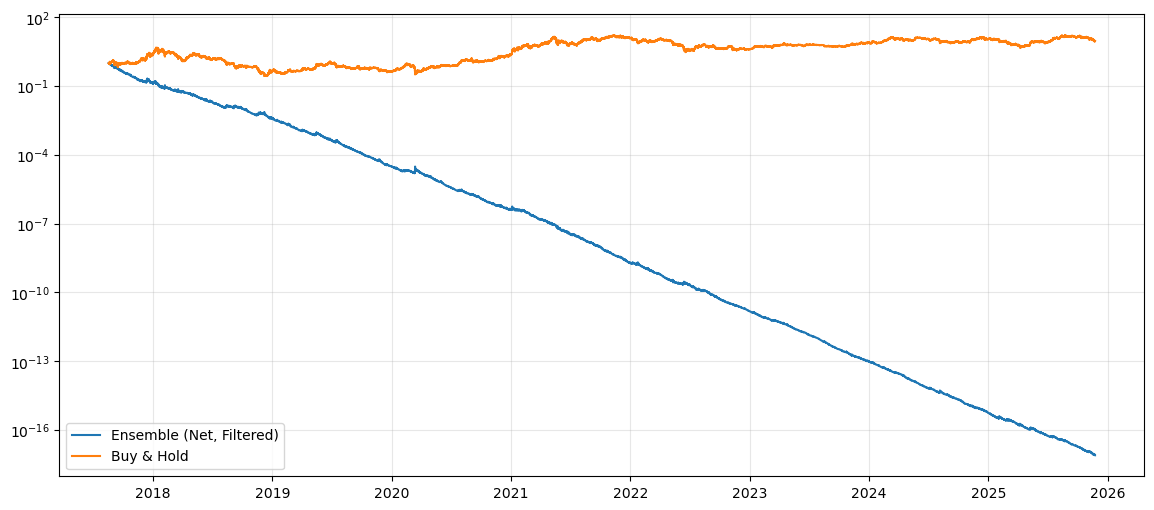

In [40]:
plt.figure(figsize=(14,6))
plt.plot(data_filtered['equity'], label='Ensemble (Net, Filtered)')
plt.plot(data_filtered['buy_hold'], label='Buy & Hold')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [42]:
data_nocost, total_trades = run_ensemble_backtest(
    df,
    windows=sensitive_window,
    vol_window=24,
    k=1.0,
    z_threshold=0.5,
    long_only=False,
    fee_rate=0.00,
    slippage=0.000
)

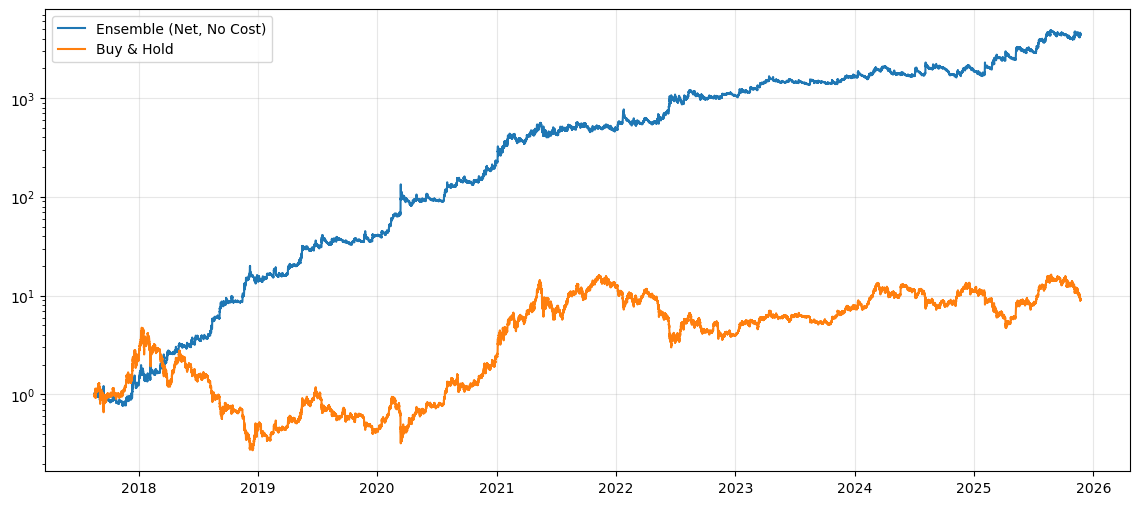

In [43]:
plt.figure(figsize=(14,6))
plt.plot(data_nocost['equity'], label='Ensemble (Net, No Cost)')
plt.plot(data_nocost['buy_hold'], label='Buy & Hold')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
print(f"Total number of trades executed in the backtest: {total_trades}") 

36740

Number of total trades has decreased, but we still have a long way to go.
The startegy performing well without costs is still a good sign

Now, let us set a minimum holding period

In [70]:
def enforce_minimum_holding_period(position_series, min_holding):
    """
    position_series: pd.Series of raw positions (already trend-filtered)
    min_holding: int, number of bars to hold at minimum
    """
    pos = position_series.copy().values
    n = len(pos)
    
    last_change_idx = 0  # index of last position change
    
    for i in range(1, n):
        # if position changed
        if pos[i] != pos[i-1]:
            # if we have not held long enough
            if (i - last_change_idx) < min_holding:
                # revert change — enforce old position
                pos[i] = pos[i-1]
            else:
                # accept the change
                last_change_idx = i
    
    return pd.Series(pos, index=position_series.index)

import numpy as np
import pandas as pd

def calculate_perf_metrics(equity_curve, returns, freq_per_year=365*24):  # hourly data
    # equity_curve: pd.Series of equity values (normalized to 1 at start)
    # returns: pd.Series of strategy returns (log returns)
    # freq_per_year: how many bars in a year (for hourly = 8760)
    perf = {}
    simple_returns = np.exp(returns) - 1

    # Total Return
    perf['Total Return'] = equity_curve.iloc[-1] - 1
    # Annualized Return
    periods = len(equity_curve)
    years = periods / freq_per_year
    perf['Annualized Return'] = (equity_curve.iloc[-1])**(1/years) - 1
    # Sharpe Ratio (use excess return if you have risk free rate)
    perf['Sharpe Ratio'] = (simple_returns.mean() / simple_returns.std()) * np.sqrt(freq_per_year)
    # Max Drawdown
    roll_max = equity_curve.cummax()
    drawdown = 1 - equity_curve / roll_max
    perf['Max Drawdown'] = drawdown.max()
    # Calmar Ratio
    if perf['Max Drawdown'] > 0:
        perf['Calmar Ratio'] = perf['Annualized Return'] / perf['Max Drawdown']
    else:
        perf['Calmar Ratio'] = np.nan
    return perf

def run_ensemble_backtest(
    df,
    windows,
    vol_window=24,
    k=1.0,
    z_threshold=0.5,
    long_only=False,
    fee_rate=0.001,
    slippage=0.0003,
    min_holding=6,
    freq_per_year=365*24  # default hourly frequency
):
    data = df.copy()

    # --- Build ensemble z-score ---
    data['z_ensemble'] = build_ensemble_signal(data, windows, vol_window=vol_window)

    # --- Raw ensemble positions ---
    raw_pos = build_ensemble_positions(
        data,
        'z_ensemble',
        k=k,
        z_threshold=z_threshold,
        long_only=long_only
    )
    data['position_raw'] = raw_pos

    # --- Trend Regime Filter ---
    pos = data['position_raw'].copy()
    pos[data['trend_regime'] == 1] = np.clip(pos[data['trend_regime'] == 1], 0, 1)
    pos[data['trend_regime'] == -1] = np.clip(pos[data['trend_regime'] == -1], -1, 0)
    pos[data['trend_regime'] == 0] = 0
    data['position'] = pos

    # --- MINIMUM HOLDING PERIOD ---
    data['position'] = enforce_minimum_holding_period(
        data['position'],
        min_holding=min_holding
    )

    # --- Execution delay ---
    data['position_shifted'] = data['position'].shift(1).fillna(0)

    # --- Trading costs ---
    # --- Trading costs ---
    data['trade'] = (data['position'] != data['position'].shift(1)).astype(float)

    cost_per_trade = fee_rate + slippage

# raw log return
    log_r = data['position_shifted'] * data['log_return']

    # convert log → simple
    gross_simple = np.exp(log_r) - 1

    # apply costs in simple space
    net_simple = gross_simple - data['trade'] * cost_per_trade

    # simple → log (safe compounding)
    data['strat_return'] = np.log1p(net_simple)


    data = data.dropna().copy()

    # --- Equity curves ---
    data['equity'] = np.exp(data['strat_return'].cumsum())
    data['buy_hold'] = np.exp(data['log_return'].cumsum())

    # Normalize
    data['equity'] /= data['equity'].iloc[0]
    data['buy_hold'] /= data['buy_hold'].iloc[0]

    total_trades = int(data['trade'].sum())

    # --- Performance metrics ---
    perf_metrics = calculate_perf_metrics(
        data['equity'],
        data['strat_return'],
        freq_per_year=freq_per_year
    )
    # For buy & hold too
    buyhold_perf = calculate_perf_metrics(
        data['buy_hold'],
        data['log_return'],
        freq_per_year=freq_per_year
    )

    return data, total_trades, perf_metrics, buyhold_perf


In [ ]:
data_mhp, total_trades, perf_metrics, buyhold_perf = run_ensemble_backtest(
    df,
    windows=sensitive_window,
    min_holding=,              # 6-hour minimum holding period
    fee_rate=0.001,             # 0.10%
    slippage=0.0003             # 0.03%
)
print(f"Total number of trades executed in the backtest: {total_trades}")

Total number of trades executed in the backtest: 2722


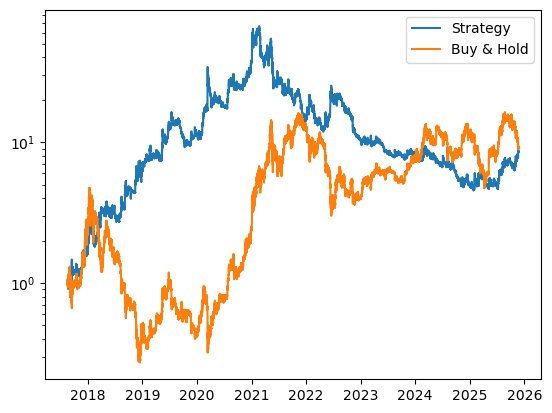

In [72]:
plt.plot(data_mhp['equity'], label='Strategy')
plt.plot(data_mhp['buy_hold'], label='Buy & Hold')
plt.yscale('log')
plt.legend()

In [73]:
perf_metrics

{'Total Return': np.float64(7.458843963160145),
 'Annualized Return': np.float64(0.2951142878124011),
 'Sharpe Ratio': np.float64(0.7210672236618739),
 'Max Drawdown': 0.9314905047088277,
 'Calmar Ratio': np.float64(0.31681942684391634)}

In [74]:
buyhold_perf

{'Total Return': np.float64(8.357488402915957),
 'Annualized Return': np.float64(0.31104811112336095),
 'Sharpe Ratio': np.float64(0.7547409731646606),
 'Max Drawdown': 0.9425790176169281,
 'Calmar Ratio': np.float64(0.3299968547037756)}